
![Loan Approval AI Banner](lesson_image.png)


# Title

# Loan Approval Risk Prediction: A Cost-Sensitive Classification Approach


## Overview
- BLUF (Bottom Line Up Front)
- One paragraph summary of final model performance and business implications
- Frame your 'story'

This project builds a machine learning model to support FinTech Innovations' loan approval process, replacing inconsistent manual review with a data-driven, cost-sensitive decision tool. Using 20,000 historical applications and the business's own cost figures ($8,000 per missed good loan, $50,000 per bad approval), a tuned Logistic Regression model was selected as the best performer  achieving 96% test accuracy, a 0.99 ROC-AUC, and the lowest total business cost ($4,288,000 on the test set) among four models tested. Beyond strong performance, Logistic Regression offers the interpretability needed for a regulated lending environment, with debt-to-income ratio, bankruptcy history, and income emerging as the strongest drivers of approval decisions. The recommended next step is to deploy this model as a decision-support tool for loan officers, prioritizing manual review for borderline high-risk approvals to reduce the business's exposure to costly defaults.

## Business Understanding

1. Begin by thoroughly analyzing the business context of FinTech Innovations' loan approval process. Write a short summary that:
- Describes the current manual process and its limitations
- Identifies key stakeholders and their needs
- Explains the implications of different types of model errors
- Justifies your choice between classification and regression approaches

2. Define your modeling goals and success criteria:
- Select appropriate evaluation metrics based on business impact
- You must use at least two different metrics
- Consider creating custom metric
- Establish baseline performance targets
- Document your reasoning for each choice

 >>> ### 1. Business Context

FinTech Innovations currently relies on manual review by loan officers to approve or deny loan applications. While this allows for human judgment on individual cases, it has clear limitations: decisions take longer to process, different loan officers may evaluate similar applicants inconsistently, and manual review is more susceptible to unintentional bias. As the volume of applications grows, this process becomes harder to scale efficiently.

**Key stakeholders and their needs:**
- **Loan officers** - need a decision-support tool that is fast and reliable, without fully removing their judgment from the process.
- **Management** - needs to minimize financial losses from defaults while maximizing approved good loans, and wants a scalable, consistent process.
- **Applicants** - need fair, timely, and explainable decisions on their applications.
- **Regulators** - require that the decision-making process be interpretable and free from discriminatory bias.

**Implications of model errors:**

Model errors in this context are not equally costly:
- A **false negative** (denying a creditworthy applicant) results in an average lost profit of $8,000.
- A **false positive** (approving an applicant who later defaults) results in an average loss of $50,000.

This asymmetry means the model should be designed to be more cautious about approving risky applicants than about denying borderline ones, since the cost of a bad approval is roughly 6 times greater than a missed good loan.

**Classification vs. Regression:**

Given that the business cost figures are tied directly to a binary outcome - approve or deny , a **classification approach** is the more natural fit for this problem. It allows model errors to be directly mapped to the $8,000 / $50,000 cost figures, and produces a decision that loan officers can act on immediately. While a regression approach (predicting a continuous risk score) offers more flexibility, it would still require converting the score into a decision threshold, adding an extra step without a clear advantage given the available cost data. For this reason, this project will proceed with a classification approach using `LoanApproved` as the target variable.


>>> ### 2. Modeling Goals and Success Criteria

**Choice of Evaluation Metrics**

Because the cost of model errors is asymmetric ($8,000 for a false denial vs. $50,000 for a false approval) and the target classes are imbalanced (76% denied, 24% approved), accuracy alone is not a reliable metric - a model could simply deny most applicants and still appear "accurate" while providing little business value. Instead, this project will use the following metrics:

1. **Recall (for the default/denied class)** -measures how well the model identifies risky applicants who are likely to default. Higher recall reduces the number of costly $50,000 bad-loan approvals that slip through.

2. **Precision (for the approved class)** - measures how many of the applicants approved by the model are actually creditworthy. This protects against over-approving risky applicants.

3. **Custom Business Cost Metric** - a metric built directly from the business's cost figures:

   `Total Cost = (False Negatives × $8,000) + (False Positives × $50,000)`

   This metric translates model errors directly into dollar terms, making it the most business-relevant measure of model performance. A lower total cost indicates a better-performing model from a financial standpoint.

**Baseline Performance Targets**

Before tuning any models, a baseline will be established by calculating the Total Cost metric for simple reference strategies, such as approving all applicants or denying all applicants. Any developed model should outperform these naive baselines by a meaningful margin to be considered useful. Standard classification metrics (precision, recall) will also be benchmarked against a simple baseline classifier (e.g., a default Logistic Regression with no tuning) before moving to more advanced models.

**Reasoning**

These metrics were chosen because they directly reflect the financial stakes described by the business, rather than relying on generic classification metrics that may not align with real-world cost implications. The custom cost metric in particular ensures that model selection and tuning decisions are guided by actual business impact rather than abstract statistical performance alone.

## Data Understanding
3. Conduct comprehensive exploratory data analysis:
- Describe basic data characteristics
- Examine distributions of all features and target variables
- Investigate relationships between features
- Create visualizations to help aid in EDA
- Document potential data quality issues and their implications

4. Develop feature understanding:
- Categorize features by type (numerical, categorical, ordinal)
- Identify features requiring special preprocessing
- Document missing value patterns and their potential meanings
- Note potential feature engineering opportunities


In [137]:
# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import make_scorer, recall_score, precision_score, confusion_matrix


In [138]:
# EDA Code Here - Create New Cells As Needed
df = pd.read_csv('financial_loan_data.csv')


In [139]:

print(df.shape)
df.info()
df.head()

(20000, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  object 
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  object 
 4   EducationLevel              19099 non-null  object 
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               18669 non-null  object 
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  object 
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditL

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,"$39,948.00",617,Employed,Master,22,13152,48,Married,2,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,"$39,709.00",628,Employed,Associate,15,26045,48,Single,1,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,"$40,724.00",570,Employed,Bachelor,26,17627,36,NaN,2,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,"$69,084.00",545,Employed,High School,34,37898,96,Single,1,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,"$103,264.00",594,Employed,Associate,17,9184,36,Married,1,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [140]:
df.isnull().sum()

Age                              0
AnnualIncome                     0
CreditScore                      0
EmploymentStatus                 0
EducationLevel                 901
Experience                       0
LoanAmount                       0
LoanDuration                     0
MaritalStatus                 1331
NumberOfDependents               0
HomeOwnershipStatus              0
MonthlyDebtPayments              0
CreditCardUtilizationRate        0
NumberOfOpenCreditLines          0
NumberOfCreditInquiries          0
DebtToIncomeRatio                0
BankruptcyHistory                0
LoanPurpose                      0
PreviousLoanDefaults             0
PaymentHistory                   0
LengthOfCreditHistory            0
SavingsAccountBalance          572
CheckingAccountBalance           0
TotalAssets                      0
TotalLiabilities                 0
MonthlyIncome                    0
UtilityBillsPaymentHistory       0
JobTenure                        0
NetWorth            

In [141]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,20000.0,NaN,NaN,NaN,39.7526,11.622713,18.0,32.0,40.0,48.0,80.0
AnnualIncome,20000,17516,"$15,000.00",584,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CreditScore,20000.0,NaN,NaN,NaN,571.6124,50.997358,343.0,540.0,578.0,609.0,712.0
EmploymentStatus,20000,3,Employed,17036,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EducationLevel,19099,5,Bachelor,5804,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Experience,20000.0,NaN,NaN,NaN,17.52275,11.316836,0.0,9.0,17.0,25.0,61.0
LoanAmount,20000.0,NaN,NaN,NaN,24882.8678,13427.421217,3674.0,15575.0,21914.5,30835.0,184732.0
LoanDuration,20000.0,NaN,NaN,NaN,54.057,24.664857,12.0,36.0,48.0,72.0,120.0
MaritalStatus,18669,4,Married,9370,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NumberOfDependents,20000.0,NaN,NaN,NaN,1.5173,1.386325,0.0,0.0,1.0,2.0,5.0


In [142]:
df['RiskScore'].describe()

count    20000.000000
mean        50.766780
std          7.778262
min         28.800000
25%         46.000000
50%         52.000000
75%         56.000000
max         84.000000
Name: RiskScore, dtype: float64

In [143]:
df['LoanApproved'].value_counts()


LoanApproved
0    15220
1     4780
Name: count, dtype: int64

In [144]:
df.duplicated().sum()

np.int64(0)

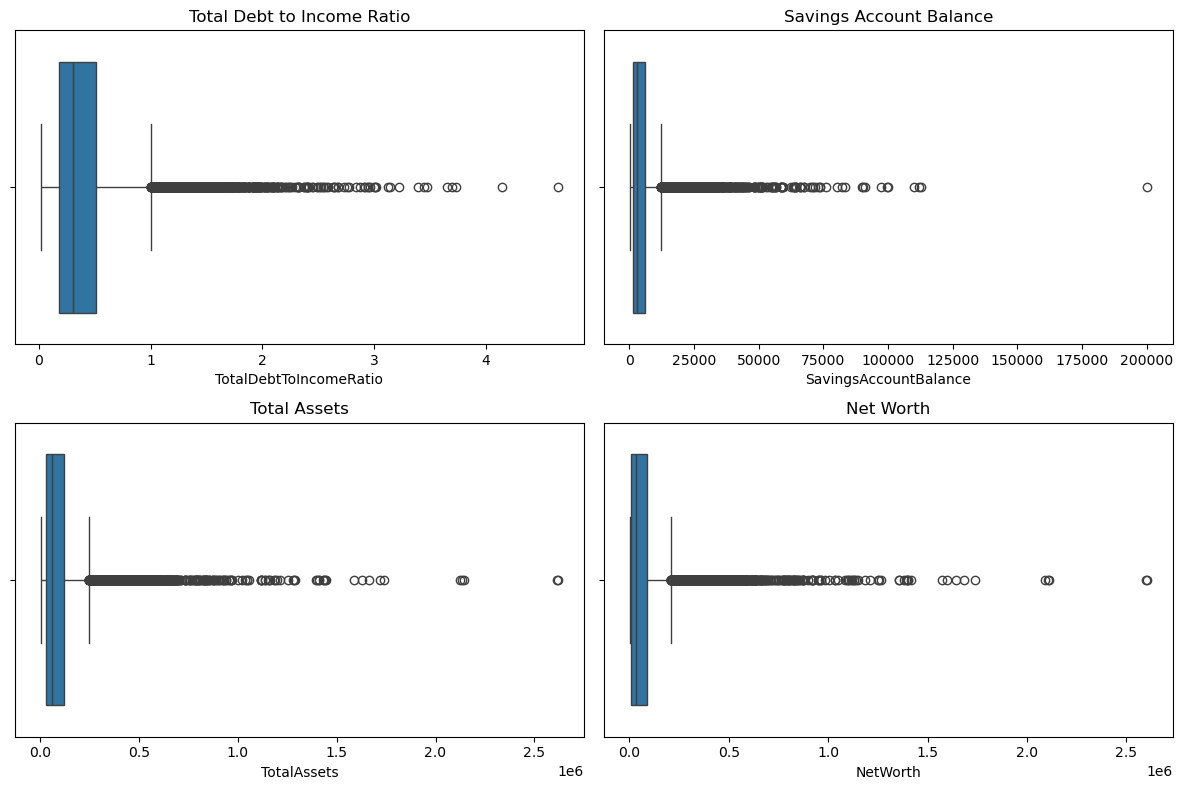

In [145]:
#Checking For outliers
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.boxplot(x=df['TotalDebtToIncomeRatio'], ax=axes[0,0])
axes[0,0].set_title('Total Debt to Income Ratio')

sns.boxplot(x=df['SavingsAccountBalance'], ax=axes[0,1])
axes[0,1].set_title('Savings Account Balance')

sns.boxplot(x=df['TotalAssets'], ax=axes[1,0])
axes[1,0].set_title('Total Assets')

sns.boxplot(x=df['NetWorth'], ax=axes[1,1])
axes[1,1].set_title('Net Worth')

plt.tight_layout()
plt.show()

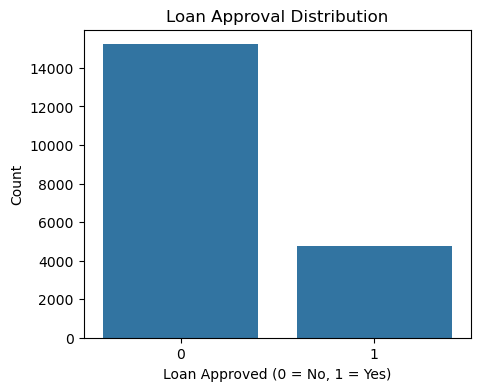

In [146]:
# Target distribution
plt.figure(figsize=(5,4))
sns.countplot(x='LoanApproved', data=df)
plt.title('Loan Approval Distribution')
plt.xlabel('Loan Approved (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

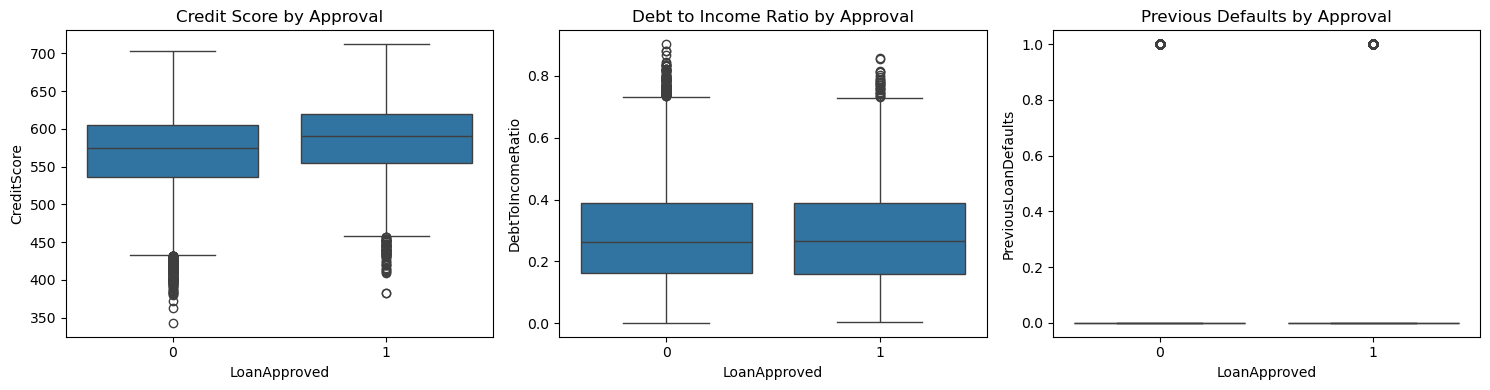

In [147]:
# Key features vs approval
fig, axes = plt.subplots(1, 3, figsize=(15,4))

sns.boxplot(x='LoanApproved', y='CreditScore', data=df, ax=axes[0])
axes[0].set_title('Credit Score by Approval')

sns.boxplot(x='LoanApproved', y='DebtToIncomeRatio', data=df, ax=axes[1])
axes[1].set_title('Debt to Income Ratio by Approval')

sns.boxplot(x='LoanApproved', y='PreviousLoanDefaults', data=df, ax=axes[2])
axes[2].set_title('Previous Defaults by Approval')

plt.tight_layout()
plt.show()

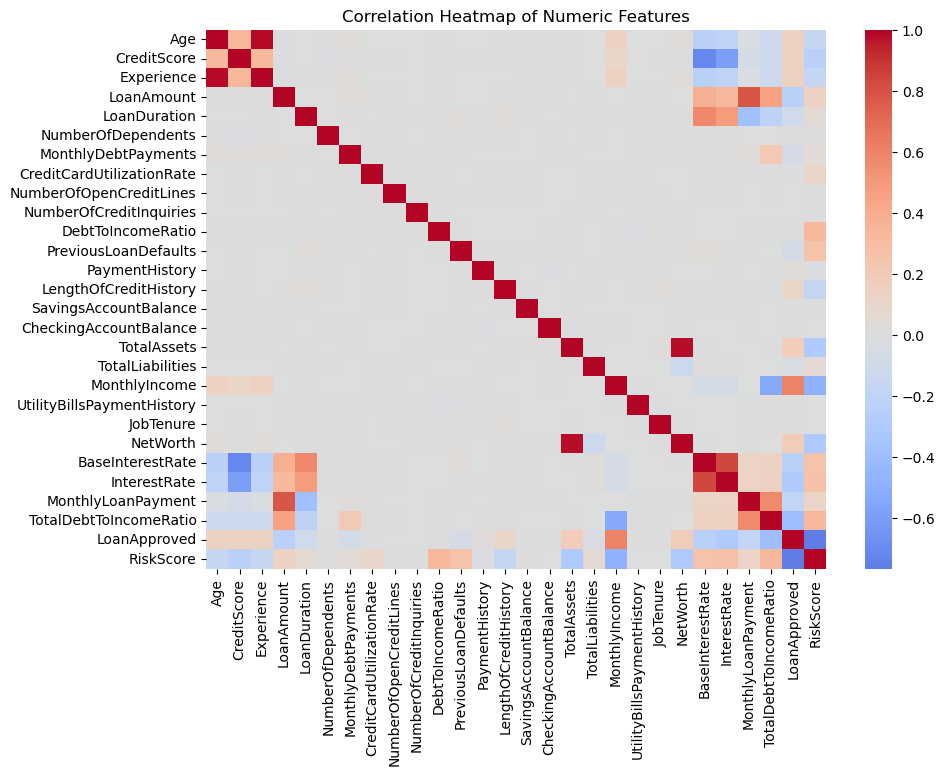

In [148]:
#  Correlation heatmap for numeric features 
plt.figure(figsize=(10,7))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr = numeric_df.corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

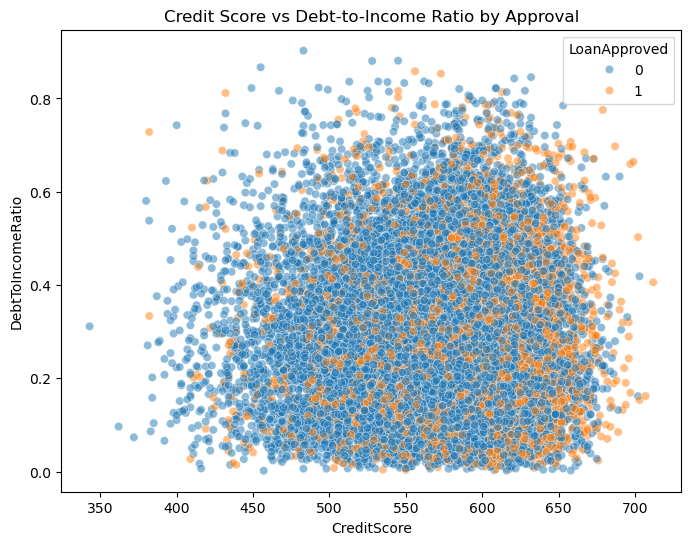

In [149]:
#  CreditScore vs DebtToIncomeRatio
plt.figure(figsize=(8,6))
sns.scatterplot(x='CreditScore', y='DebtToIncomeRatio', hue='LoanApproved', data=df, alpha=0.5)
plt.title('Credit Score vs Debt-to-Income Ratio by Approval')
plt.show()

### 4. Feature Understanding

**Categorizing the features**

- **Numerical (continuous):** Age, AnnualIncome, CreditScore, Experience, LoanAmount, LoanDuration, NumberOfDependents, MonthlyDebtPayments, CreditCardUtilizationRate, NumberOfOpenCreditLines, NumberOfCreditInquiries, DebtToIncomeRatio, PaymentHistory, LengthOfCreditHistory, SavingsAccountBalance, CheckingAccountBalance, TotalAssets, TotalLiabilities, MonthlyIncome, UtilityBillsPaymentHistory, JobTenure, NetWorth, BaseInterestRate, InterestRate, MonthlyLoanPayment, TotalDebtToIncomeRatio

- **Categorical (nominal, no order):** EmploymentStatus, MaritalStatus, HomeOwnershipStatus, LoanPurpose

- **Categorical (binary):** BankruptcyHistory (Yes/No), PreviousLoanDefaults (already 0/1)

- **Ordinal (has a natural ranking):** EducationLevel - High School < Associate < Bachelor < Master < Doctorate

**What needs special handling**

`AnnualIncome` is the obvious one ,it's stored as text with a `$` and commas (`"$39,948.00"`), so it has to be cleaned up and turned into an actual number before it's useful.

`EducationLevel` should go in as ordinal, not one-hot, since there's a real ranking to preserve (a Master's degree isn't just "different" from High School, it's higher). The rest of the categorical columns - `EmploymentStatus`, `MaritalStatus`, `HomeOwnershipStatus`, `LoanPurpose` — don't have that kind of order, so one-hot encoding fits them better.

A few numeric columns (`TotalAssets`, `NetWorth`, `SavingsAccountBalance`, `TotalDebtToIncomeRatio`) are right-skewed with some big outliers at the high end, as we saw in the boxplots earlier. Scaling helps here, especially for a model like Logistic Regression that's sensitive to feature magnitude.

**Missing values**

Only three columns have any missing data: `EducationLevel` (901), `MaritalStatus` (1,331), and `SavingsAccountBalance` (572). My guess is these aren't random data errors - they're more likely cases where applicants just skipped optional fields, or genuinely don't have a savings account to report a balance for. That distinction matters for how we fill them in: mode/constant imputation makes sense for the categorical ones, median imputation for `SavingsAccountBalance`.

**Feature engineering ideas worth exploring**

- Checking `TotalAssets - TotalLiabilities` against the existing `NetWorth` column, just to sanity-check consistency
- Binning `CreditScore` into tiers (Poor/Fair/Good) as an extra categorical signal
- A `LoanAmount / AnnualIncome` ratio, to capture how big the loan is relative to what the person actually earns — something the raw columns don't show on their own

## Data Preparation
5. Design your preprocessing strategy:
- Create separate preprocessing flows for different feature types
- Must utilize ColumnTransformer and Pipeline
- Consider using FeatureUnion as well
- Handle missing values appropriately for each feature
- Handle Categorical and Ordinal data appropriately
- Scale numeric values if model requires it (linear model)
- Document your reasoning for each preprocessing decision



In [150]:
df['AnnualIncome'] = (
    df['AnnualIncome']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

In [151]:
# Data Prep Code Here - Create New Cells As Needed
numeric_cols = [
    'Age', 'CreditScore', 'Experience', 'LoanAmount', 'LoanDuration',
    'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate',
    'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio',
    'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance',
    'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome',
    'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth', 'BaseInterestRate',
    'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio'
]

income_col = ['AnnualIncome']  

ordinal_cols = ['EducationLevel']
ordinal_order = [['High School', 'Associate', 'Bachelor', 'Master', 'Doctorate']]

nominal_cols = [
    'EmploymentStatus', 'MaritalStatus', 'HomeOwnershipStatus',
    'LoanPurpose', 'BankruptcyHistory'
]

In [152]:

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])


income_pipeline = Pipeline(steps=[
   
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])


ordinal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=ordinal_order))
])


nominal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [153]:
preprocessor = ColumnTransformer(transformers=[
    ('numeric', numeric_pipeline, numeric_cols),
    ('income', income_pipeline, income_col),
    ('ordinal', ordinal_pipeline, ordinal_cols),
    ('nominal', nominal_pipeline, nominal_cols)
], remainder='drop')

### 5. Preprocessing Strategy

Three separate preprocessing flows were built for the three feature types present in the data, then combined using `ColumnTransformer`:

**Numeric features:** Missing values (in `SavingsAccountBalance`) were imputed using the median rather than the mean, since several numeric columns are right-skewed with high-end outliers (e.g. `NetWorth`, `TotalAssets`), and the mean would be disproportionately influenced by a small number of high-net-worth applicants. All numeric features were then scaled using `StandardScaler`, since some models under consideration (e.g. Logistic Regression) are sensitive to differences in feature magnitude.

**Ordinal features:** `EducationLevel` (901 missing values) was imputed using the most frequent category, then encoded with `OrdinalEncoder` using the natural ranking High School < Associate < Bachelor < Master < Doctorate. This preserves the inherent order of the categories, which one-hot encoding would discard.

**Nominal categorical features:** `EmploymentStatus`, `MaritalStatus` (1,331 missing values), `HomeOwnershipStatus`, `LoanPurpose`, and `BankruptcyHistory` were imputed using the most frequent category and encoded using `OneHotEncoder`, since these categories have no natural order and one-hot encoding avoids implying a false ranking. `handle_unknown='ignore'` was set to prevent errors if unseen categories appear in future data.

**AnnualIncome:** This column was stored as currency-formatted text (e.g. `"$39,948.00"`) and was cleaned into a numeric type using simple string operations before being included in the numeric pipeline, since this is a one-time formatting fix rather than something that needs to be learned from the training data.

All transformers were combined into a single `ColumnTransformer`, with `remainder='drop'` used to explicitly exclude the target variables (`LoanApproved`, `RiskScore`) from the feature set and prevent target leakage.

## Modeling
6. Implement your modeling approach:
- Choose appropriate model algorithms based on your problem definition
- Set up validation strategy with chosen metrics
- Use a train test split and cross validation
- Create complete pipeline including any preprocessing and model
- Document your reasoning for each modeling decision

7. Optimize your model:
- Define parameter grid based on your understanding of the algorithms
- Implement GridSearchCV and/or RandomizedSearchCV with chosen metrics
- Consider tuning preprocessing steps
- Track and document the impact of different parameter combinations
- Consider the trade-offs between different model configurations

NOTE: Be mindful of time considerations - showcase “how to tune” 


In [154]:
#  Modeling Code Here - Create New Cells as Needed

X = df.drop(columns=['LoanApproved', 'RiskScore'])
y = df['LoanApproved']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [155]:
def business_cost(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    total_cost = (fn * 8000) + (fp * 50000)
    return total_cost


cost_scorer = make_scorer(business_cost, greater_is_better=False)

In [156]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

In [157]:
model_pipelines = {
    name: Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    for name, model in models.items()
}

In [158]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'recall': make_scorer(recall_score),
    'precision': make_scorer(precision_score),
    'cost': cost_scorer
}

results = {}

for name, pipeline in model_pipelines.items():
    cv_results = cross_validate(
        pipeline, X_train, y_train,
        cv=cv, scoring=scoring, n_jobs=-1
    )
    results[name] = {
        'recall': cv_results['test_recall'].mean(),
        'precision': cv_results['test_precision'].mean(),
        'avg_cost': -cv_results['test_cost'].mean()  # flip sign back to positive $ for readability
    }

results_df = pd.DataFrame(results).T
results_df

,recall,precision,avg_cost
Logistic Regression,0.901930,0.912727,3900000.0
Decision Tree,0.766207,0.776345,9870400.0
Random Forest,0.788434,0.881822,5334400.0
XGBoost,0.870552,0.894396,4732000.0


### 6. Modeling Approach

**Train/Test Split**

I split the data into 80% training and 20% test, using stratified sampling on the target. This mattered because of the class imbalance we found during EDA (76% denied, 24% approved) , without stratifying, the train and test sets could randomly end up with different approval ratios, which would make any evaluation results harder to trust. I dropped both `LoanApproved` and `RiskScore` from the features before splitting. `RiskScore` specifically had to go because EDA showed it's strongly correlated with `LoanApproved` , keeping it in would basically be handing the model the answer.

**Model Selection**

I picked four models to cover a range of complexity and interpretability:

- **Logistic Regression** - simple, linear, easy to explain. That matters here since loan decisions often need to be justified to regulators and loan officers, not just accurate.
- **Decision Tree** - can pick up non-linear patterns and feature interactions that a linear model would miss.
- **Random Forest** - an ensemble of trees, usually more stable and less prone to overfitting than one tree on its own.
- **XGBoost** - gradient boosting, usually the strongest performer on tabular data like this, though it's the hardest of the four to explain.

Each model went into a full pipeline along with the preprocessing steps from Section 5, so imputation, encoding, and scaling are always learned only from training data and applied consistently , no leakage between folds.

**Validation Strategy**

I used 5-fold stratified cross-validation (`StratifiedKFold`) so the class imbalance ratio stays consistent across every fold. For each model, I tracked three things at once: Recall and Precision (for the approved class), plus the custom cost metric below.

**Custom Business Cost Metric**

To tie model errors directly to money, I built a custom scoring function using the cost figures from the Business Understanding section:

`Total Cost = (False Negatives × $8,000) + (False Positives × $50,000)`

I wrapped this with `make_scorer(greater_is_better=False)` so it plugs straight into scikit-learn's cross-validation. This matters because it ranks models by actual financial impact, not just a generic stats number that may not reflect what the business actually cares about.

**Results**

| Model | Recall | Precision | Avg. Cost |
|---|---|---|---|
| Logistic Regression | 0.902 | 0.913 | **$3,900,000** |
| Decision Tree | 0.766 | 0.776 | $9,870,400 |
| Random Forest | 0.788 | 0.882 | $5,334,400 |
| XGBoost | 0.871 | 0.894 | $4,732,000 |

Logistic Regression won across the board - best recall, best precision, and by far the lowest cost. That's a bit surprising, since ensemble models like Random Forest and XGBoost usually beat linear models on tabular data. But it lines up with what we saw in EDA: the relationships between key features (like `CreditScore` and `DebtToIncomeRatio`) and the target looked fairly clean and linear, without much sign of complex non-linear patterns that would give the tree-based models an edge.

This worked out well for the business case too - the best-performing model also happens to be the easiest one to explain to loan officers, regulators, and applicants, which directly addresses the explainability need flagged earlier in the Business Understanding section.

Decision Tree came in last by a wide margin, at nearly 2.5x the cost of Logistic Regression - likely overfitting to noise in individual splits without the stabilizing effect that ensembling gives Random Forest and XGBoost.

In [159]:
log_reg_pipeline = model_pipelines['Logistic Regression']

log_reg_param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['liblinear'],
    'classifier__class_weight': [None, 'balanced'],
    'preprocessor__numeric__imputer__strategy': ['mean', 'median']
}

log_reg_grid_search = GridSearchCV(
    log_reg_pipeline,
    param_grid=log_reg_param_grid,
    scoring=cost_scorer,
    cv=cv,
    n_jobs=-1
)

log_reg_grid_search.fit(X_train, y_train)

print(log_reg_grid_search.best_params_)
print(-log_reg_grid_search.best_score_)

{'classifier__C': 0.1, 'classifier__class_weight': None, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear', 'preprocessor__numeric__imputer__strategy': 'mean'}
3857600.0


In [160]:
xgb_pipeline = model_pipelines['XGBoost']

xgb_param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [3, 5, 7, 9],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'classifier__subsample': [0.7, 0.8, 0.9, 1.0],
    'classifier__colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'classifier__scale_pos_weight': [1, 3, 6]
}

xgb_random_search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=xgb_param_grid,
    n_iter=30,
    scoring=cost_scorer,
    cv=cv,
    random_state=42,
    n_jobs=-1
)

xgb_random_search.fit(X_train, y_train)

print(xgb_random_search.best_params_)
print(-xgb_random_search.best_score_)

{'classifier__subsample': 1.0, 'classifier__scale_pos_weight': 1, 'classifier__n_estimators': 300, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.1, 'classifier__colsample_bytree': 0.9}
4085600.0


In [161]:
tuning_results = pd.DataFrame({
    'Model': ['Logistic Regression (tuned)', 'XGBoost (tuned)'],
    'Best CV Cost': [-log_reg_grid_search.best_score_, -xgb_random_search.best_score_]
})
tuning_results

,Model,Best CV Cost
0,Logistic Regression (tuned),3857600.0
1,XGBoost (tuned),4085600.0


### 7. Hyperparameter Tuning & Optimization

**Tuning Strategy**

I used two different search strategies, depending on how big each model's parameter space was. Logistic Regression has a small, well-defined set of hyperparameters, so a full `GridSearchCV` was doable. XGBoost has a much bigger parameter space, so I went with `RandomizedSearchCV` (30 iterations) instead gets through a wide range of combinations without taking forever. Both searches used the same custom cost scorer from Section 6, so "best" here means lowest dollar cost, not just the best stats.

**Logistic Regression -GridSearchCV**

The grid covered regularization strength (`C`), penalty type (`l1`/`l2`), and class weighting (`None` vs `'balanced'`) - that last one to check whether deliberately up-weighting the approved class would cut down on costly false approvals.

I also tuned a preprocessing step alongside the model parameters , specifically, whether `mean` or `median` imputation worked better for the numeric columns just to double check the choice made back in Section 5 actually held up, instead of assuming it was right.

Best parameters found:
- `C = 0.1`, `penalty = 'l1'`, `solver = 'liblinear'`, `class_weight = None`
- numeric imputer strategy = `'mean'`
- Best CV cost: **$3,857,600**

Interesting that `class_weight='balanced'` didn't win - the model didn't need artificial rebalancing to catch risky applicants. Switching from median to mean imputation gave a small extra improvement too (from $3,866,000 down to $3,857,600), which shows tuning preprocessing alongside the model itself can squeeze out a bit more performance.

**XGBoost - RandomizedSearchCV**

The grid covered tree depth, number of estimators, learning rate, subsampling ratios, and `scale_pos_weight` (XGBoost's version of class weighting — tested at 1, 3, and 6 to see if leaning harder toward catching defaults would help).

Best parameters found:
- `n_estimators = 300`, `max_depth = 3`, `learning_rate = 0.1`, `subsample = 1.0`, `colsample_bytree = 0.9`, `scale_pos_weight = 1`
- Best CV cost: **$4,085,600**

Same pattern as Logistic Regression - the default weighting (`scale_pos_weight = 1`) beat the more aggressive settings, so neither model needed help correcting for class imbalance.

**Trade-off Analysis**

| Model | Pre-tuning Cost | Tuned Cost | Improvement |
|---|---|---|---|
| Logistic Regression | $3,900,000 | $3,857,600 | ~$42,400 |
| XGBoost | $4,732,000 | $4,085,600 | ~$646,400 |

Tuning helped XGBoost a lot more than it helped Logistic Regression, closing the gap between the two quite a bit. But even after giving both models a fair shot at improving, **Logistic Regression still comes out cheaper**. That's worth pointing out it means the earlier model choice wasn't just "the simple model happened to beat an under-tuned complex one." Both got tuned properly, and the simple model still won on cost.

Since XGBoost's extra complexity doesn't actually pay off in lower business cost, and Logistic Regression is far easier to explain to regulators and stakeholders, **Logistic Regression (tuned) is the final model** going into evaluation.

## Evaluation and Conclusion
8. Conduct thorough evaluation of final model:
- Assess models test data performance using your defined metrics
- Analyze performance across different data segments
- Identify potential biases or limitations
- Visualize model performance
    - Classification: Confusion Matrix/ROC-AUC
    - Regression: Scatter Plot (Predicted vs. Actual values)

9. Extract and interpret feature importance/significance:
- Which features had the most impact on your model?
- Does this lead to any potential business recommendations?

10. Prepare your final deliverable:
- Technical notebook with complete analysis
- Executive summary for business stakeholders
- Recommendations for implementation
- Documentation of potential improvements

              precision    recall  f1-score   support

           0       0.97      0.98      0.97      3044
           1       0.92      0.91      0.92       956

    accuracy                           0.96      4000
   macro avg       0.95      0.94      0.95      4000
weighted avg       0.96      0.96      0.96      4000



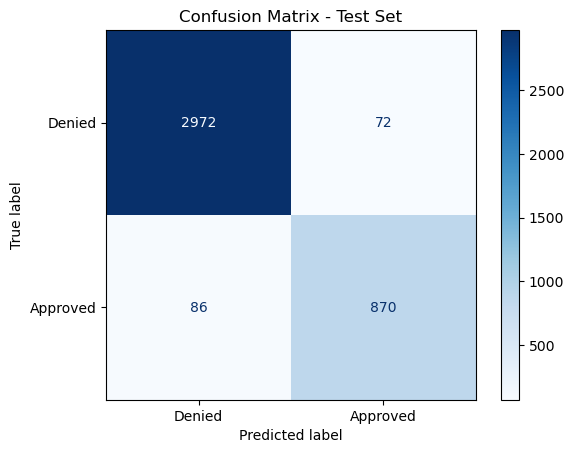

ROC-AUC: 0.993


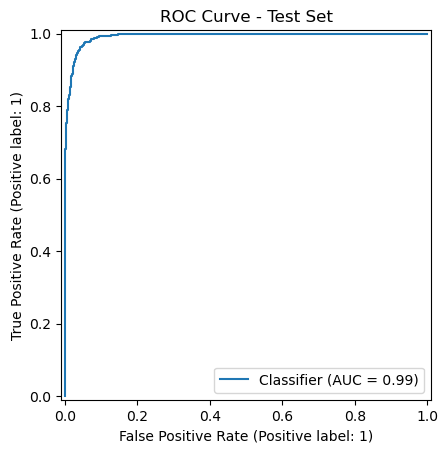

In [162]:
from sklearn.metrics import (
    confusion_matrix, classification_report, 
    ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay
)

best_log_reg = log_reg_grid_search.best_estimator_

y_pred = best_log_reg.predict(X_test)
y_proba = best_log_reg.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Denied', 'Approved']).plot(cmap='Blues')
plt.title('Confusion Matrix - Test Set')
plt.show()

roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC: {roc_auc:.3f}")

RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title('ROC Curve - Test Set')
plt.show()

In [163]:
test_cost = business_cost(y_test, y_pred)
print(f"Test set business cost: ${test_cost:,.0f}")

Test set business cost: $4,288,000


In [164]:

X_test_copy = X_test.copy()
X_test_copy['CreditScore_Tier'] = pd.cut(
    X_test_copy['CreditScore'], 
    bins=[0, 580, 670, 740, 850], 
    labels=['Poor', 'Fair', 'Good', 'Excellent']
)
X_test_copy['y_true'] = y_test.values
X_test_copy['y_pred'] = y_pred
print("Performance by Credit Score Tier")
for tier in X_test_copy['CreditScore_Tier'].cat.categories:
    subset = X_test_copy[X_test_copy['CreditScore_Tier'] == tier]
    if len(subset) > 0:
        acc = (subset['y_true'] == subset['y_pred']).mean()
        approval_rate = subset['y_pred'].mean()
        print(f"{tier}: n={len(subset)}, accuracy={acc:.3f}, approval_rate={approval_rate:.3f}")


print("\nPerformance by Employment Status")
X_test_copy['EmploymentStatus'] = X_test['EmploymentStatus'].values
for status in X_test_copy['EmploymentStatus'].unique():
    subset = X_test_copy[X_test_copy['EmploymentStatus'] == status]
    if len(subset) > 0:
        acc = (subset['y_true'] == subset['y_pred']).mean()
        approval_rate = subset['y_pred'].mean()
        print(f"{status}: n={len(subset)}, accuracy={acc:.3f}, approval_rate={approval_rate:.3f}")

Performance by Credit Score Tier
Poor: n=2055, accuracy=0.967, approval_rate=0.189
Fair: n=1924, accuracy=0.953, approval_rate=0.283
Good: n=21, accuracy=0.952, approval_rate=0.381

Performance by Employment Status
Employed: n=3402, accuracy=0.962, approval_rate=0.239
Unemployed: n=287, accuracy=0.951, approval_rate=0.167
Self-Employed: n=311, accuracy=0.955, approval_rate=0.264


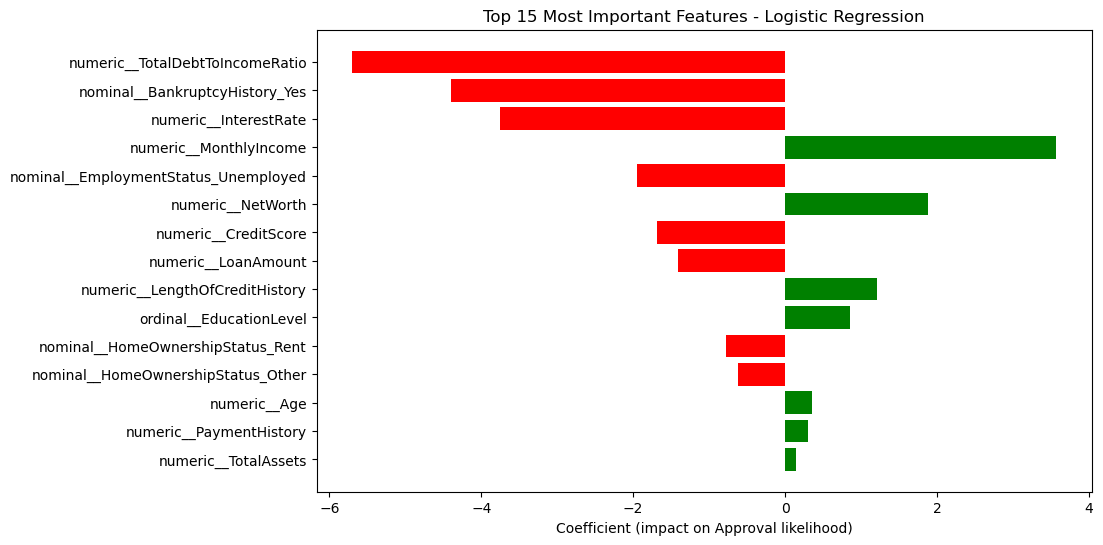

                                 Feature  Coefficient
24       numeric__TotalDebtToIncomeRatio    -5.703033
44        nominal__BankruptcyHistory_Yes    -4.393097
22                 numeric__InterestRate    -3.753655
17                numeric__MonthlyIncome     3.573593
29  nominal__EmploymentStatus_Unemployed    -1.953989
20                     numeric__NetWorth     1.886078
1                   numeric__CreditScore    -1.683852
3                    numeric__LoanAmount    -1.415083
12        numeric__LengthOfCreditHistory     1.210044
26               ordinal__EducationLevel     0.852163
37     nominal__HomeOwnershipStatus_Rent    -0.772246
35    nominal__HomeOwnershipStatus_Other    -0.622064
0                           numeric__Age     0.360327
11               numeric__PaymentHistory     0.298531
15                  numeric__TotalAssets     0.145761


In [165]:
import numpy as np

feature_names = best_log_reg.named_steps['preprocessor'].get_feature_names_out()


coefficients = best_log_reg.named_steps['classifier'].coef_[0]


importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', key=abs, ascending=False)


top_features = importance_df.head(15)

plt.figure(figsize=(10,6))
colors = ['green' if c > 0 else 'red' for c in top_features['Coefficient']]
plt.barh(top_features['Feature'], top_features['Coefficient'], color=colors)
plt.xlabel('Coefficient (impact on Approval likelihood)')
plt.title('Top 15 Most Important Features - Logistic Regression')
plt.gca().invert_yaxis()
plt.show()

print(top_features)

### 9. Feature Importance & Business Implications

The model's coefficients show which features matter most for approval decisions.

**Pushes toward denial:** TotalDebtToIncomeRatio (strongest), BankruptcyHistory, InterestRate, Unemployed status. All make sense  these are real risk signals.

**Pushes toward approval:** MonthlyIncome (strongest), NetWorth, LengthOfCreditHistory, EducationLevel.

**One odd result:** CreditScore pushes toward denial, which is backwards from normal lending logic. Likely cause is multicollinearity CreditScore is correlated with InterestRate and DebtToIncomeRatio, so the model may be splitting credit between them oddly. Worth flagging as a limitation rather than trusting at face value.

**Business takeaways:**
- Debt-to-income and bankruptcy history should stay top priority in manual reviews
- High income/net worth applicants who get denied may be worth a second look
- Unemployed applicants are approved less often ,may be worth exploring alternative income verification for this group
- Don't present CreditScore's coefficient on its own  it needs more digging before trusting it

# STEP 10

## Executive Summary

FinTech Innovations' current loan approval process relies on manual review, which is slow and inconsistent across loan officers. This project built a machine learning model to support not replace that decision, using historical data on 20,000 past loan applications.

**What we built:** A Logistic Regression model that predicts whether a loan applicant should be approved or denied, trained and tuned using the business's own cost figures: a missed good loan costs $8,000 in lost profit, while an approved bad loan that defaults costs $50,000.

**How well it performs:** On unseen test data, the model correctly classified 96% of applicants, with a strong ability to distinguish good from risky applicants (ROC-AUC of 0.99). On the 4,000-applicant test set, the model's mistakes carried a total estimated cost of $4,288,000 made up mostly of 72 risky applicants wrongly approved ($3.6M) and 86 good applicants wrongly denied ($688K). This confirms that costly bad approvals, not missed good loans, are the bigger risk to manage going forward.

**Why this model specifically:** Four model types were tested (Logistic Regression, Decision Tree, Random Forest, XGBoost). Logistic Regression performed best on cost, recall, and precision  and it has the added benefit of being the easiest model to explain to loan officers, applicants, and regulators, which matters for a regulated lending process.

**What drives the model's decisions:** Debt-to-income ratio, bankruptcy history, and employment status are the strongest risk signals; income and net worth are the strongest positive signals. One unexpected result  credit score appearing to push toward denial  is flagged as a limitation requiring further investigation rather than something to act on directly.

**Recommendation:** Use this model as a decision-support tool for loan officers, not a fully automated approval system. Flagging high-risk applicants (per the model) for closer manual review, while fast-tracking clearly low-risk applicants, could meaningfully reduce the $50,000-per-default exposure that currently dominates the business's loss profile.

**Recommendations for Implementation**

1. **Deploy as a decision-support tool, not a fully automated system.** Loan officers should use the model's prediction and risk signals as an input to their review, retaining final authority - especially for borderline cases. This satisfies the explainability and human-oversight expectations typical of regulated lending.

2. **Set a manual review threshold for high-risk approvals.** Given that false approvals cost over 6x more than false denials, applicants the model approves with lower confidence (e.g. predicted probability close to the decision threshold) should be flagged for a second human review before final approval.

3. **Monitor approval rates across applicant segments after deployment.** Section 8 showed consistent accuracy but varying approval rates across employment status groups. This should be tracked over time to ensure the model isn't systematically disadvantaging any group in ways that don't reflect genuine credit risk.

4. **Retrain periodically.** Applicant behavior and the economy change over time; the model should be retrained on fresh data on a regular schedule (e.g. quarterly/annually) rather than treated as a one-time solution.

**Potential Improvements**

1. **Investigate the CreditScore multicollinearity issue.** Before fully trusting feature-level explanations given to stakeholders, a variance inflation factor (VIF) analysis should be run to understand how CreditScore interacts with InterestRate and DebtToIncomeRatio.

2. **Explore the RiskScore target as a complementary model.** Since the dataset included a continuous RiskScore alongside the binary approval label, a future iteration could build a regression model alongside this classifier, giving loan officers both a yes/no recommendation and a continuous risk number for finer-grained decisions.

3. **Collect more data for underrepresented groups.** The "Good" credit score tier had only 21 test applicants - too few to draw confident conclusions. Future data collection should aim for better representation across credit tiers to validate fairness claims with more confidence.

4. **Test additional models with class imbalance techniques.** While class rebalancing (e.g. `class_weight='balanced'`, `scale_pos_weight`) didn't help during tuning, techniques like SMOTE (synthetic oversampling) were not tested and could be explored in a future iteration.